# SHAP analysis of the augmented MLP models



#### Imports

In [1]:
import numpy as np
import pandas as pd
from random import uniform, seed
import joblib
import shap

from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams.update({'font.size': 13})

seed(42)

#### Encode the experimental sequences

In [2]:
def seq_fingerprint(sequence):
    fp = np.zeros(len(sequence))
    for i, char in enumerate(sequence):
        if char.isupper():
            fp[i] = 1
    return fp

df321 = pd.read_csv('data/synthesized_full-deduplicated.csv')
X321 = np.array([seq_fingerprint(s) for s in df321['sequence'].astype(str).str.strip()])
X321.shape

(321, 11)

#### Load the augmented models

In [3]:
mlp_act = joblib.load('models/augmented_model_mlp_act.joblib')
mlp_hem = joblib.load('models/augmented_model_mlp_hem.joblib')

C:\Users\Maedeh\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.0.2 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Maedeh\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.0.2 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


#### Shapley plot helpers

In [4]:
def get_jitter(feature_data, scaling_factor):
    kde = gaussian_kde(feature_data)
    density = kde(feature_data)
    density = density / density.max()
    noise = [uniform(-d, d) for d in density]
    return np.array(noise) * scaling_factor

def shapley_plot(shap_values, labels, xticks, savename, colors=['#B3CCFF', '#3B6BFF']):
    # split into one 2-D array per class
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

    plt.figure(figsize=(7, 4))
    for i in range(len(shap_values)):
        for j in range(len(shap_values[0][0])):
            feature_data = shap_values[i][:, j]
            x = np.repeat(j, len(feature_data)) + get_jitter(feature_data, 0.2)
            plt.scatter(x, feature_data, color=colors[i], s=1.0)

    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.scatter([], [], color=colors[0], label=labels[0])
    plt.scatter([], [], color=colors[1], label=labels[1])

    plt.xticks(range(11), xticks)
    plt.xlabel('Residue')
    plt.ylabel('Shapley value')
    plt.legend()
    plt.savefig(f'plots/{savename}_shapley.png', dpi=1200, bbox_inches='tight')

#### Activity


Using 321 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/321 [00:00<?, ?it/s]

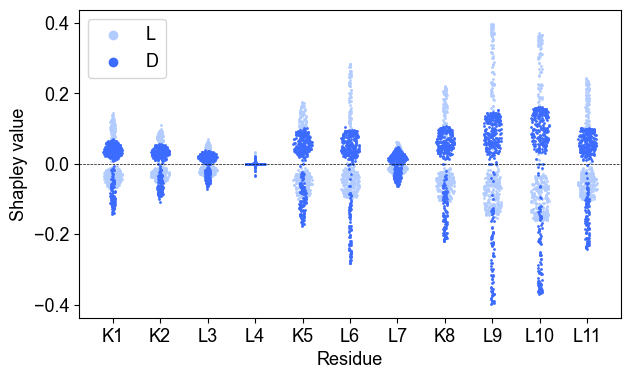

In [5]:
explainer = shap.KernelExplainer(mlp_act.predict_proba, X321)
shap_values = explainer.shap_values(X321)
shapley_plot(shap_values, ['L', 'D'], ['K1', 'K2', 'L3', 'L4', 'K5', 'L6', 'L7', 'K8', 'L9', 'L10', 'L11'], 'mlp_act')

#### Hemolysis


Using 321 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/321 [00:00<?, ?it/s]

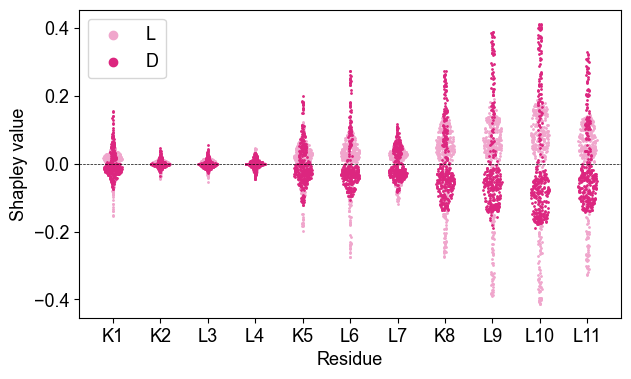

In [6]:
explainer = shap.KernelExplainer(mlp_hem.predict_proba, X321)
shap_values = explainer.shap_values(X321)
shapley_plot(shap_values, ['L', 'D'], ['K1', 'K2', 'L3', 'L4', 'K5', 'L6', 'L7', 'K8', 'L9', 'L10', 'L11'], 'mlp_hem', colors=['#F0A6CC', '#DC267F'])